Any set of spectrum can be used for template for RVSNUpy. In this notebook, I describe the way to use a set of SDSS spectra for the template set

The template set for RVSNUpy is a dictionary with the following structure:

{'template_name':[template_spectrum, template_tyupe]}

- 'template_name': A string representing the name of the template.
- template_spectrum(4 × n_pixel array): A NumPy array in the same format as the input spectrum:
    - 1st array: wavelength (in ascending order)
    - 2nd array: flux
    - 3rd array: flux uncertainty (standard deviation)
    - 4th array: An array filled with ones (used for masking; should be all ones for the templates)
- template_type: Indicates the spectral type of the template:
    - 1: Absorption-line-dominated template
    - 2: Emission-line-dominated template

Note1: template_spectrum should be in the rest frame (i.e. z=0)

Note2: Correctly specifying template_type is essential for accurate redshift measurement.
Inspect the template_spectrum: if it contains prominent emission lines, set template_type = 2; otherwise, set template_type = 1.

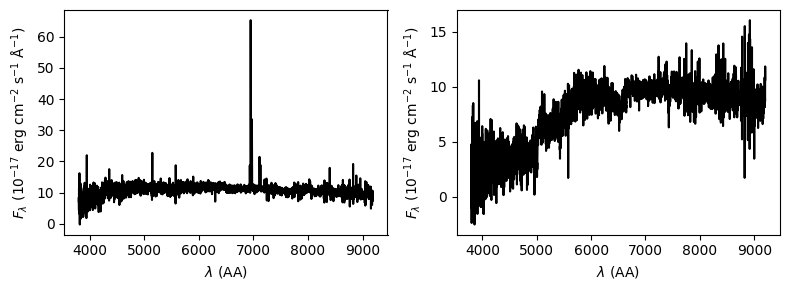

In [ ]:
# Import two sdss spectra for the templates
from RVSNUpy.spectrum_import import sdss_fits
temp1 = sdss_fits('spectra/sdss_spec3.fits')
temp2 = sdss_fits('spectra/sdss_spec6.fits')

# plotting spectra
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(8,3))

ax[0].plot(temp1[0], temp1[1], 'k-')
ax[1].plot(temp2[0], temp2[1], 'k-')

ax[0].set_xlabel(r"$\lambda~({\rm AA})$")
ax[1].set_xlabel(r"$\lambda~({\rm AA})$")
ax[0].set_ylabel(r"$F_\lambda~(10^{-17}~{\rm erg~cm^{-2}~s^{-1}~\AA^{-1}})$")
ax[1].set_ylabel(r"$F_\lambda~(10^{-17}~{\rm erg~cm^{-2}~s^{-1}~\AA^{-1}})$")

fig.tight_layout()

temp1 and temp2 are not in the rest frame, so I will blueshift these spectra to the rest frame (z=0)

In [27]:
z1 = 0.05875822287831697
z2 = 0.26090142897008617

temp1[0,:] /= (1+z1)
temp2[0,:] /= (1+z2)

Now, let's construct a dictionary for a template set. Distinctive emission lines are visible in temp1, whereas temp2 shows no strong emission features. Therefore, we assign template_type = 2 for temp1 and template_type = 1 for temp2.


In [28]:
templates = {}
templates['temp1'] = [temp1, 2]
templates['temp2'] = [temp2, 1]

Let's test the redshift measurement with this template set

In [30]:
# Read sdss spectrum
from RVSNUpy.spectrum_import import sdss_fits
sdss_spec = sdss_fits('spectra/sdss_spec1.fits')

from RVSNUpy.rvm import rvm
measure = rvm(templates)

df=measure.z_single(sdss_spec)
print(df)

  template_name         z      zerr          r   chi_eff  note
0         temp1  0.168387  0.000081  14.665868  1.148249      
1         temp2  0.168228  0.000119   6.538795  3.007557  best
